---
# title: "My Notebook"
format:
  html:
    toc: true           # ✅ Table of contents (outline)
    toc-location: left  # ✅ Place TOC in the left sidebar
    number-sections: true
    code-fold: true
    code-summary: "Show Code"
    theme: cosmo        # Optional themes: cosmo, flatly, default, etc.
---

How to use database and basics of SQL for data organization. There are several popular database management systems (DBMS) such as MySQL, PostgreSQL, SQLite, and Microsoft SQL Server. SQL is the standard language for interacting with relational databases.

For the spatial datasets, we can use PostGIS, which is a spatial extension for PostgreSQL that adds support for geographic objects. Just imagin it the shapefile has limited capabilities, like if you features is more than 1million, the shapefile or the geojson would be too large to handle. You really need to think about a more scalable method to handle the huge amount of datasets.

The database system is just the operation system for datasets. We will not cover too much about database in this class, but I want to introduce some basic concept of database, therefore, you know how to get started and where to go next.

Here I am going to use several simple example to illustrate how to use database to store and manage datasets. 

In [112]:
import sqlite3

# Create a new database file (or connect if it already exists)
conn = sqlite3.connect("students.db")

# Create a cursor object to run SQL commands
cur = conn.cursor()

In [113]:
cur.execute("""
CREATE TABLE IF NOT EXISTS students (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT,
    major TEXT,
    gpa REAL
)
""")
conn.commit()

In [114]:
cur.execute("INSERT INTO students (name, major, gpa) VALUES (?, ?, ?)",
            ("Alice", "Urban Studies", 3.8))
cur.execute("INSERT INTO students (name, major, gpa) VALUES (?, ?, ?)",
            ("Bob", "Environmental Science", 3.5))
conn.commit()

In [115]:
cur.execute("SELECT * FROM students")
rows = cur.fetchall()

for row in rows:
    print(row)

(1, 'Alice', 'Urban Studies', 3.8)
(2, 'Bob', 'Environmental Science', 3.5)


In [ ]:
cur.execute("UPDATE students SET gpa = 3.9 WHERE name = 'Alice'")
cur.execute("DELETE FROM students WHERE name = 'Bob'")
conn.commit()

# Week 10B<br>Getting Data, Part 2: Working with APIs


**Week #7 Agenda**

**Last time**:

- Introduction to APIs
- Natural language processing via Philly's 311 API
    - Word frequencies

**Today:**

- Natural language processing via Philly's 311 API
    - Sentiment analysis
- Pulling census data and shape files via the Census API

In [1]:
# Data analysis
import geopandas as gpd
import numpy as np
import pandas as pd

# APIs
import requests

# Plotting
import seaborn as sns
from matplotlib import pyplot as plt
import holoviews as hv
import hvplot.pandas

In [2]:
pd.options.display.max_columns = 999
pd.options.display.max_colwidth = None

## Part 1: Picking up where we left off

## Natural Language Processing and the 311 Request API

Today, we'll continue our analysis of 311 request descriptions queried through the API for the Philly 311 system, available at: [https://iframe.publicstuff.com/#?client_id=242](https://iframe.publicstuff.com/#?client_id=242)

We'll focus on *sentiment analysis* today.

Let's load the data from the 311 API first:

In [3]:
# Store the data we request
data = []

# Total number of pages
total_pages = 3

# Loop over each page
for page_num in range(1, total_pages + 1):
    # Print out the page number
    print(f"Getting data for page #{page_num}...")

    # Make the request
    r = requests.get(
        "https://vc0.publicstuff.com/api/2.0/requests_list",
        params={
            "client_id": 242,  # Unique identifier for Philadelphia
            "page": page_num,  # What page of data to pull
            "limit": 200,  # How many rows per page
        },
    )

    # Get the json
    d = r.json()

    # Add the new data to our list and save
    data = data + [r["request"] for r in d["response"]["requests"]]

# Create a dataframe
data = pd.DataFrame(data)

Getting data for page #1...
Getting data for page #2...
Getting data for page #3...


In [4]:
len(data)

600

In [5]:
data.head()

,id,image_thumbnail,title,description,status,address,location,zipcode,foreign_id,date_created,count_comments,count_followers,count_supporters,lat,lon,user_follows,user_comments,user_request,rank,user,primary_attachment
0,17489478,,Abandoned Automobile,White Ford Pickup truck with flat tires,submitted,"1551 W Oakdale St, Philadelphia, PA 19132, USA",,None,18600586,1761065574,0,0,0,39.993987,-75.157633,0,0,0,1,,NaN
1,17489468,,Traffic Sign Complaint,"The intersection of Bryan St & the 100 block of W Durham is frequently blocked by cars parking too far into the intersection. Sunday night (10/19), a firetruck & ambulance couldn’t make the turn from Bryan onto W Durham because cars were blocking the street. This isn’t the first time, either. The SEPTA Connect buses frequently have to go the wrong way down Bryan (a one-way street) to get onto our block to pick up senior citizens. We need signs and poles to prevent folks from parking within 20ft of the curb on BOTH Bryan & W Durham so that the street is accessible to emergency services.",submitted,"7134 Bryan St,Philadelphia, PA 19119","Philadelphia, Pennsylvania",19119,18600556,1761065436,0,0,0,40.058059,-75.191227,0,0,0,1,,NaN
2,17489463,,Abandoned Automobile,1554 West Oakdale ST on 16th St an abandoned van blocking view onto turning 16th St,submitted,"1554 W Oakdale St, Philadelphia, PA 19132, USA",,None,18600550,1761065404,0,0,0,39.993794,-75.157819,0,0,0,1,,NaN
3,17489438,https://d17aqltn7cihbm.cloudfront.net/uploads/small_8cf24349cc017097a8bfd5cabb576f86,Graffiti Removal Request,Wall tagged after 141 Brown on the left-hand side under the bridge,submitted,"149 Brown St,Philadelphia, PA 19123","Philadelphia, Pennsylvania",19123,18600520,1761065169,0,0,0,39.962864,-75.139928,0,0,0,1,,"{'id': 5711724, 'extension': 'jpg', 'content_type': 'image/jpeg', 'url': 'https://d17aqltn7cihbm.cloudfront.net/uploads/8cf24349cc017097a8bfd5cabb576f86', 'versions': {'small': 'https://d17aqltn7cihbm.cloudfront.net/uploads/small_8cf24349cc017097a8bfd5cabb576f86', 'medium': 'https://d17aqltn7cihbm.cloudfront.net/uploads/medium_8cf24349cc017097a8bfd5cabb576f86', 'large': 'https://d17aqltn7cihbm.cloudfront.net/uploads/large_8cf24349cc017097a8bfd5cabb576f86'}}"
4,17489431,https://d17aqltn7cihbm.cloudfront.net/uploads/small_4fa29433b1ef33e875a5bebf40d589b1,Vacant Property Complaint,,submitted,"2547 N 2nd St, Philadelphia, PA 19133, USA",,None,18600515,1761065081,0,0,0,39.989458,-75.135098,0,0,0,1,,"{'id': 5711717, 'extension': 'jpg', 'content_type': 'image/jpeg', 'url': 'https://d17aqltn7cihbm.cloudfront.net/uploads/4fa29433b1ef33e875a5bebf40d589b1', 'versions': {'small': 'https://d17aqltn7cihbm.cloudfront.net/uploads/small_4fa29433b1ef33e875a5bebf40d589b1', 'medium': 'https://d17aqltn7cihbm.cloudfront.net/uploads/medium_4fa29433b1ef33e875a5bebf40d589b1', 'large': 'https://d17aqltn7cihbm.cloudfront.net/uploads/large_4fa29433b1ef33e875a5bebf40d589b1'}}"


Let's remove rows with missing descriptions and get our list of descriptions:

In [20]:
# Remove rows with missing descriptions
data = data.dropna(subset=["description"])
data_final = data.loc[data["description"] != ""]

# Strip out spaces and convert to a list
descriptions = data_final["description"].str.strip().tolist()

And then run our steps to clean up our text data:

1. Break strings into words
1. Remove capitalization
1. Remove stop words
1. Remove punctuation

**1. Break strings into words**

Use the `.split()` command to break a string into words by splitting on spaces.

In [21]:
descriptions_words = [desc.split() for desc in descriptions]

In [25]:
# len(descriptions_words)

This is a list of lists, e.g., the first element is a list of words. Let's *flatten* this into a list of just words:

In [26]:
descriptions_words_flat = []

for list_of_words in descriptions_words:
    for word in list_of_words:
        descriptions_words_flat.append(word)

**2. Convert all words to lower case**

Use `.lower()` makes all words lower cased

In [27]:
descriptions_words_lower = [word.lower() for word in descriptions_words_flat]

**3. Remove stop words**

Common words that do not carry much significance and are often ignored in text analysis.

In [28]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/xiaojiang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Get the list of common stop words:

In [29]:
stop_words = list(set(nltk.corpus.stopwords.words("english")))

stop_words[:10]

['won',
 'couldn',
 'now',
 'about',
 "hasn't",
 "haven't",
 's',
 't',
 'hers',
 'under']

In [30]:
descriptions_no_stop = []

for word in descriptions_words_lower:
    if word not in stop_words:
        descriptions_no_stop.append(word)

In [31]:
len(descriptions_no_stop)

5550

**4. Remove punctuation**

Get the list of common punctuation:

In [32]:
import string

In [33]:
punctuation = list(string.punctuation)

In [35]:
punctuation[:5]

['!', '"', '#', '$', '%']

Remove punctuation from words:

In [36]:
descriptions_final = []

# Loop over all words
for word in descriptions_no_stop:
    
    # Remove any punctuation from the words
    for p in punctuation:
        word = word.replace(p, "")
        
    # Save it if the string is not empty
    if word != "":
        descriptions_final.append(word)

Convert to a Dataframe with one column:

In [37]:
words = pd.DataFrame({"words": descriptions_final})

In [38]:
words.head()

,words
0,white
1,ford
2,pickup
3,truck
4,flat


### Use case #1: calculating word frequencies

An example of **text mining**

Use a pandas groupby and sort to put in descending order:

In [39]:
N = words.groupby("words", as_index=False).size().sort_values("size", ascending=False, ignore_index=True)

The top 15 words by frequency:

In [40]:
top15 = N.head(15)

top15

,words,size
0,street,107
1,trash,106
2,car,51
3,property,47
4,please,40
5,side,37
6,st,37
7,block,36
8,left,35
9,sidewalk,34


**Plot the frequencies**

Use `seaborn` to plot our DataFrame of word counts...

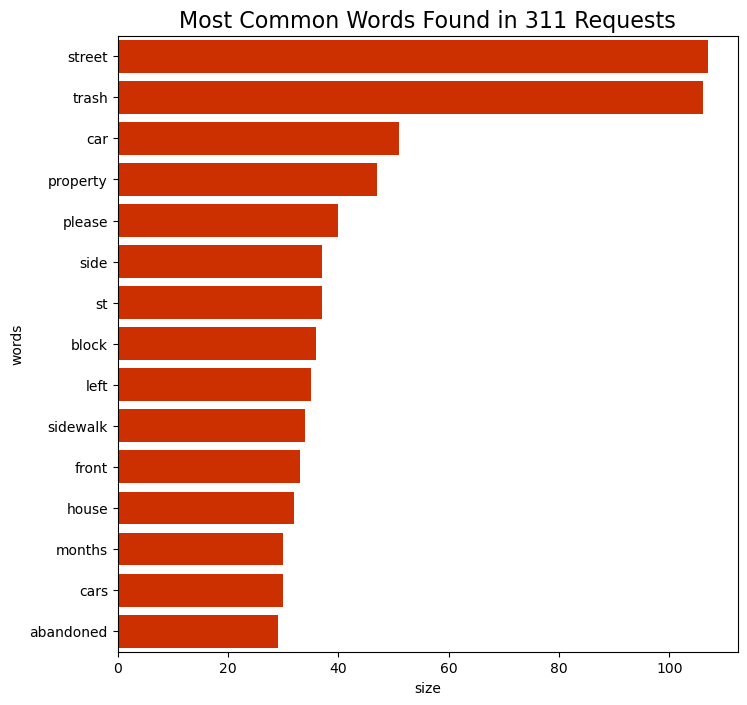

In [41]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot horizontal bar graph
sns.barplot(
    y="words",
    x="size",
    data=top15,
    ax=ax,
    color="#cc3000",
    saturation=1.0,
)

ax.set_title("Most Common Words Found in 311 Requests", fontsize=16);

**Takeaway:** Philly cares about trash! They don't call it Filthadelphia for nothing...

Now, let's visualize with a **word cloud**

Use the [wordcloud](https://amueller.github.io/word_cloud/) package to make a simple word cloud of the word frequencies. 

::: {.callout-note}

We'll need to pass a single string to the WordCloud function. We can combine a list of strings by using the join function and specifying the join separator to be a space (" ")

```python
> strings = ["this", "is", "an", "example"]

> combined_string = " ".join(strings)

> combined_string
'this is an example'
```

:::

In [14]:
# !pip install wordcloud

In [42]:
from wordcloud import WordCloud

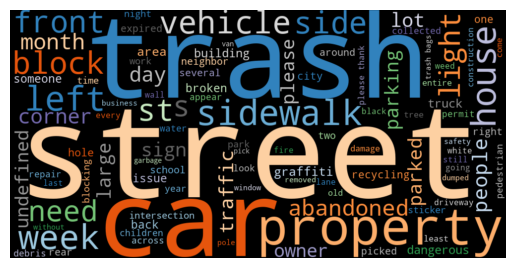

In [43]:
# Create a word cloud object
wc = WordCloud(
    background_color="black", max_words=100, width=1000, height=500, colormap="tab20c"
)

# NEW: Create a single string from all of our descriptions
text = " ".join(descriptions_final)

# Generate the image
img = wc.generate(text)

# The matplotlib fig/ax
fig, ax = plt.subplots()

# Show the image
ax.imshow(img, interpolation="bilinear")

# Format
ax.set_axis_off()
plt.show();

### Use case #2: sentiment analysis

The goal of a **sentiment analysis** is to determine the attitude or emotional state of the person who wrote a piece of text. It is often used by brands to evaluate public opinion about a product. 

**The goal**

Determine the "sentiment" of every word in the English language

*The hard way*

Train a machine learning algorithm to classify words as positive vs. negative, given an input training sample of words.

*The easy way*

Luckily, this is a **very common** task in NLP and there are several packages available that have done the hard work for you. 

They provide out-of-the-box sentiment analysis using pre-trained machine learning algorithms.

#### The `textblob` package

First, let's try out a package called `textblob`. Textblob can calculate the "polarity" of words, from negative -1 to postive +1. 

It's algorithm is not particularly sophisticated (as we will see). It was trained on IMDB movie reviews and uses a dictionary mapping of adjectives to sentiment values. So, it knows about a set of adjectives and an approximate *polarity* for those words. 

Let's try it out on the words from the 311 requests

In [10]:
# !pip install textblob

In [44]:
import textblob

First, copy our "words" dataframe and drop any duplicate words. We'll try to calculate the sentiment for each word.

In [45]:
sentiment = words.copy().drop_duplicates(subset=['words'])

In [46]:
sentiment.head()

,words
0,white
1,ford
2,pickup
3,truck
4,flat


Now, create our "text blob" objects:

In [47]:
blobs = [textblob.TextBlob(word) for word in sentiment['words']]

Now use the ".polarity" attribute to calculate the sentiment:

In [48]:
sentiment["polarity"] = [blob.polarity for blob in blobs]

In [49]:
sentiment.head(10)

,words,polarity
0,white,0.000
1,ford,0.000
2,pickup,0.000
3,truck,0.000
4,flat,-0.025
5,tires,0.000
6,intersection,0.000
7,bryan,0.000
8,st,0.000
9,100,0.000


Most of these words are zero!

In [50]:
(sentiment['polarity'] == 0).sum()

1747

In [51]:
len(sentiment)

1900

Why did this happen?

Because the universe of words that TextBlob knows about is pretty small! Mostly confined to common adjectives/adverbs that appeared in its IMDB review dataset.

Let's take a look at the words with nonzero polarity:

In [52]:
sentiment_nonzero = sentiment.query("polarity != 0")

What are the top 15 most positive words?

In [53]:
sentiment_nonzero.sort_values("polarity", ascending=False, ignore_index=True).head(15)

,words,polarity
0,best,1.0
1,happy,0.8
2,hazardous,0.6
3,kind,0.6
4,nice,0.6
5,kindly,0.6
6,touching,0.5
7,many,0.5
8,appropriate,0.5
9,sure,0.5


What are the top 15 most negative words?

In [54]:
sentiment_nonzero.sort_values("polarity", ascending=True, ignore_index=True).head(15)

,words,polarity
0,worst,-1.000000
1,disgusting,-1.000000
2,filthy,-0.800000
3,violent,-0.800000
4,ugly,-0.700000
5,bad,-0.700000
6,badly,-0.700000
7,impossible,-0.666667
8,dirty,-0.600000
9,cutting,-0.600000


What about a histogram of the sentiment?

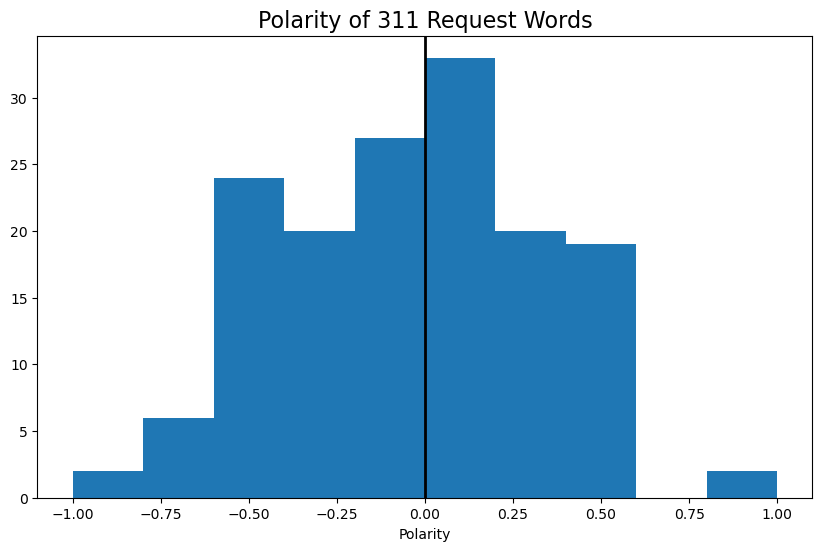

In [55]:
# create a figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# histogram
ax.hist(sentiment_nonzero["polarity"], bins="auto")
ax.axvline(x=0, c="k", lw=2)

# format
ax.set_xlabel("Polarity")
ax.set_title("Polarity of 311 Request Words", fontsize=16);

Hmm...this is surprising! There are many more positive words than I would have guessed!

**What could be going on?**


Most of the 311 requests are in fact *very* negative. They are mostly complaints, after all.

In the previous analysis, TextBlob only knows the sentiment for a *small* subset of the words. This is makes it difficult to produce a comprehensive sentiment for the entirety of the text for each 311 request. This is difficult because context really matters! Let's see an example:

As you can see in the below example, the negation is not picked up by the algorithm: 

In [56]:
textblob.TextBlob("Philly 311 is the best").polarity

1.0

In [57]:
textblob.TextBlob("Philly 311 is NOT the best").polarity

1.0

Both are marked as positive! (because of the word "best")

Can we do better? YES!

#### The `transformers` package

The Hugging Face `transformers` package ([documentation](https://huggingface.co/docs/transformers/index)) provides access to state-of-the-art, pre-trained machine learning algorithms for natural language processing. 

It provides access to more sophisticated machine learning models that are capable of measuring the sentiment of a piece of text using the full context of the words.



We can use the transformers `pipeline()` function to load and run our pre-trained models

In [49]:
# !pip install transformers
!pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 MB 1.2 MB/s eta 0:00:0000:0100:02


In [53]:
from transformers import pipeline
import torch

#### Positive/Negative sentiment analysis

We'll start with a version of the [DistilBERT](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english) model that has been fine-tuned on the [Stanford Sentiment Treebank](https://huggingface.co/datasets/sst2) dataset.

For an input series of text, this model will predict the POSITIVE / NEGATIVE labels with associated confidence scores. It will tell us how likely it thinks the text is positive or negative.

::: {.callout-tip}
For more info on sentiment analysis with the `transformers` package, check out this [tutorial](https://huggingface.co/docs/transformers/tasks/sequence_classification).
:::

In [55]:
import torch  # <--- Required to avoid NameError
from transformers import pipeline

model = "distilbert-base-uncased-finetuned-sst-2-english"

sentiment_classifier = pipeline(
    task="sentiment-analysis",
    model=model,
    tokenizer=model,
    top_k=None,
    truncation=True
)

result = sentiment_classifier("I love using AI for urban planning!")
print(result)

NameError: name 'torch' is not defined

Now, let's pass our original list of request descriptions to the classifier. 

::: {.callout-note}
We don't need to do any text pre-processing here! We'll just pass in the raw text, so no need to remove stop words, punctuation, etc.
:::


We're now running a much more sophisticated model, so it will take more time to execute! This will likely take 2-3 minutes to run...

In [56]:
%%time

scores = sentiment_classifier(descriptions)

NameError: name 'sentiment_classifier' is not defined

What does the response structure look like?

For each description, we get a dictionary containing the label (`POSITIVE` or `NEGATIVE`) and the associated score:

In [114]:
scores[:10]

[[{'label': 'POSITIVE', 'score': 0.9495417475700378},
  {'label': 'NEGATIVE', 'score': 0.050458285957574844}],
 [{'label': 'POSITIVE', 'score': 0.508097231388092},
  {'label': 'NEGATIVE', 'score': 0.49190279841423035}],
 [{'label': 'NEGATIVE', 'score': 0.6410784721374512},
  {'label': 'POSITIVE', 'score': 0.35892152786254883}],
 [{'label': 'NEGATIVE', 'score': 0.9990324974060059},
  {'label': 'POSITIVE', 'score': 0.000967523199506104}],
 [{'label': 'NEGATIVE', 'score': 0.9988860487937927},
  {'label': 'POSITIVE', 'score': 0.0011139643611386418}],
 [{'label': 'NEGATIVE', 'score': 0.9983736276626587},
  {'label': 'POSITIVE', 'score': 0.001626323675736785}],
 [{'label': 'NEGATIVE', 'score': 0.8497042059898376},
  {'label': 'POSITIVE', 'score': 0.15029579401016235}],
 [{'label': 'NEGATIVE', 'score': 0.8308085799217224},
  {'label': 'POSITIVE', 'score': 0.1691913902759552}],
 [{'label': 'POSITIVE', 'score': 0.9935035109519958},
  {'label': 'NEGATIVE', 'score': 0.006496530957520008}],
 [{'la

Let's unpack this to a more useful format:

In [116]:
yes_no = pd.DataFrame([{d["label"]: d["score"] for d in dd} for dd in scores]).assign(
    text=descriptions
)

In [117]:
yes_no.head()

,POSITIVE,NEGATIVE,text
0,0.949542,0.050458,On the southwest corner of the intersection of S. 46th Street and Woodland Avenue.
1,0.508097,0.491903,On the 'No Dumping' street sign on the south side of Cedar Avenue about 11 steps west of S. 46th Street. Next to the tiny park.
2,0.358922,0.641078,Apartment complex is dumping trash on our street again! Please help or tell me the proper channels I need to take. Thank you!
3,0.000968,0.999032,People speed up the street like they’re all 95 it needs to have street cushions put in or speed bumps whatever you wanna call
4,0.001114,0.998886,This vehicle has been parked on the 5300 block of Sycamore Street. The car appears to be stolen and parts from the vehicle were removed such as Steering wheel – and other items


**Note:** The scores summed across both labels will sum up to 1. 


**Total sentiment calculation**:
We can calculate the overall score by multiplying the value for each label, e.g., (POSITIVE = +1 and NEGATIVE = -1) by the confidence score for each label. This gives an overall sentiment estimate for each piece of text:

In [118]:
yes_no["sentiment"] = (yes_no["POSITIVE"] * +1) + (yes_no["NEGATIVE"] * -1)

In [119]:
yes_no.head()

,POSITIVE,NEGATIVE,text,sentiment
0,0.949542,0.050458,On the southwest corner of the intersection of S. 46th Street and Woodland Avenue.,0.899083
1,0.508097,0.491903,On the 'No Dumping' street sign on the south side of Cedar Avenue about 11 steps west of S. 46th Street. Next to the tiny park.,0.016194
2,0.358922,0.641078,Apartment complex is dumping trash on our street again! Please help or tell me the proper channels I need to take. Thank you!,-0.282157
3,0.000968,0.999032,People speed up the street like they’re all 95 it needs to have street cushions put in or speed bumps whatever you wanna call,-0.998065
4,0.001114,0.998886,This vehicle has been parked on the 5300 block of Sycamore Street. The car appears to be stolen and parts from the vehicle were removed such as Steering wheel – and other items,-0.997772


**Question:** Are most of the reviews positive or negative?


Let's take a look at the mean and median:

In [120]:
yes_no['sentiment'].mean()

-0.708985571766335

In [121]:
yes_no['sentiment'].median()

-0.9924230165779591

Ah! By far, most of these are negative!

Philadelphians using the 311 system appear to be *very* upset.

Let's take a look at the overall histogram of sentiment too:

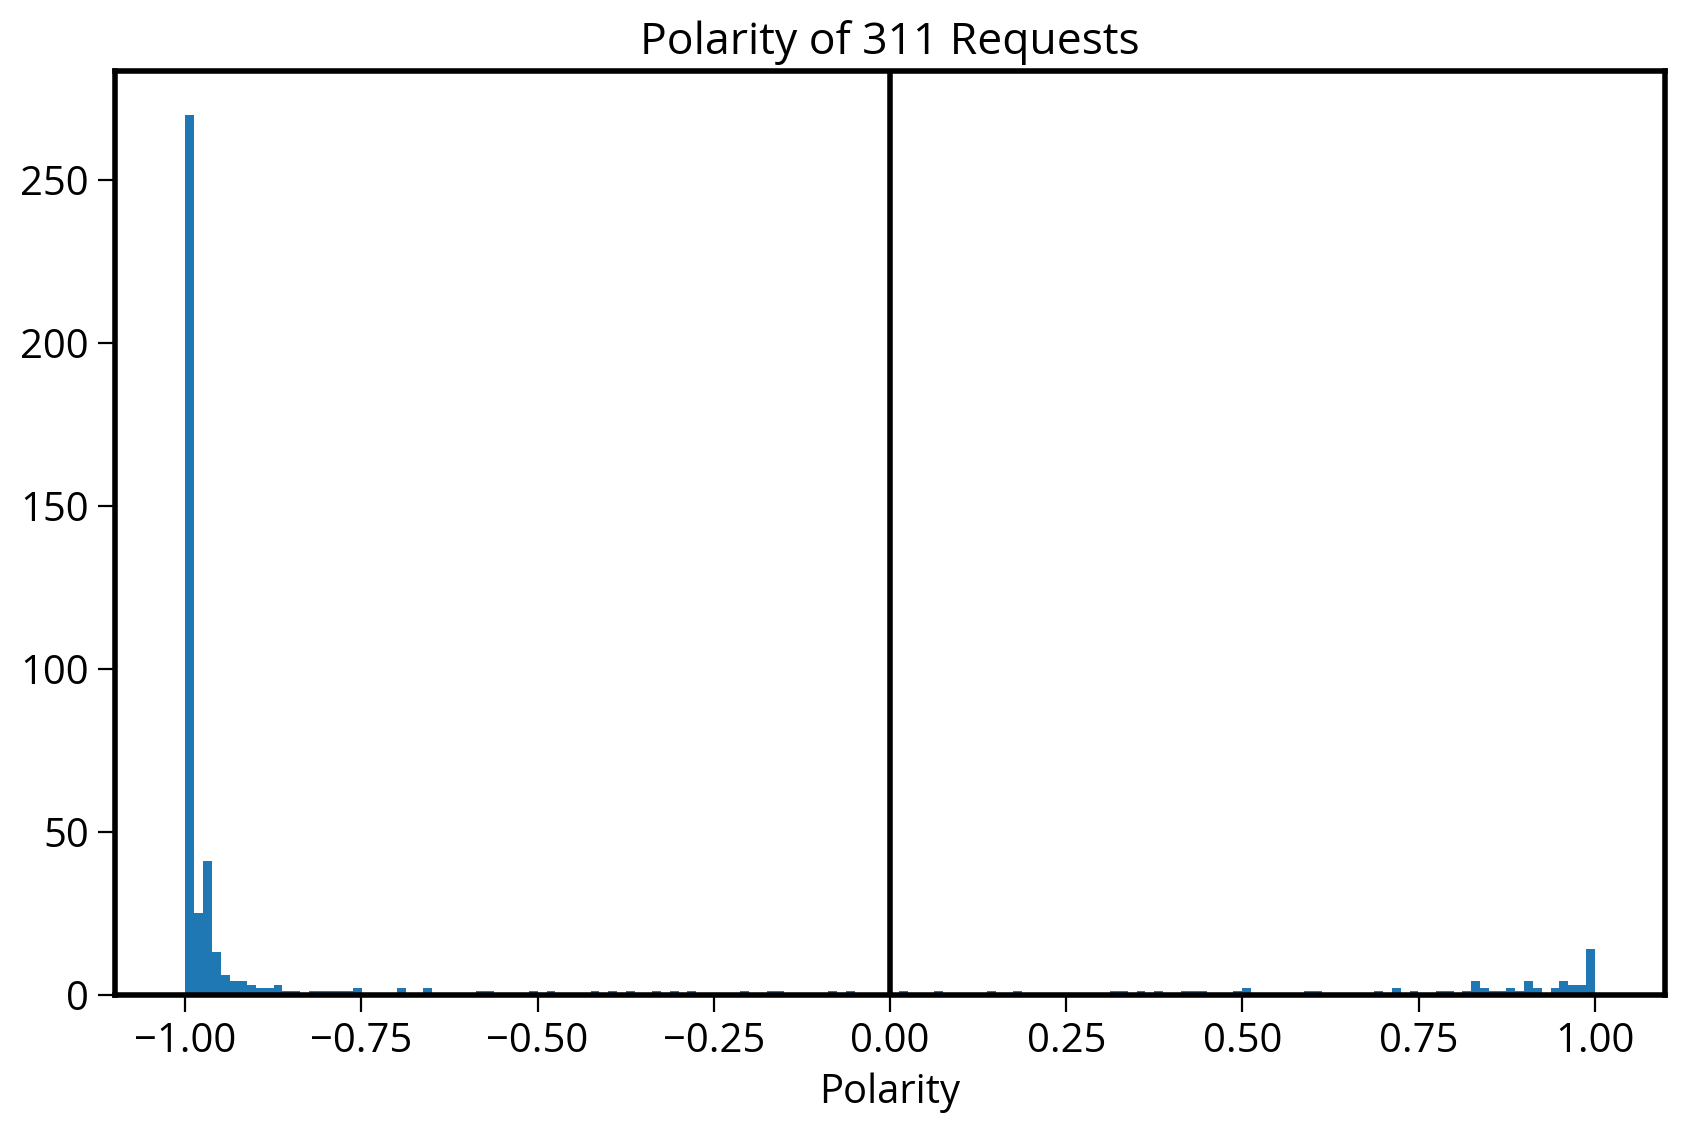

In [128]:
# Create a figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram
ax.hist(yes_no['sentiment'], bins="auto")
ax.axvline(x=0, c="k", lw=2)

# Format
ax.set_xlabel("Polarity")
ax.set_title("Polarity of 311 Requests", fontsize=16);

Whoa! Very negative sentiment!

**This makes much more sense than our earlier results with the Textblob package.**

Let's look at the 10 requests with the lowest sentiment scores:

In [129]:
yes_no.sort_values("sentiment", ascending=True).head(10)

,POSITIVE,NEGATIVE,text,sentiment
388,0.000206,0.999794,Expired tags and appears abandoned,-0.999587
89,0.000217,0.999783,Sewer is letting out really bad smell and is full of garbage.,-0.999565
74,0.000240,0.999760,sidewalk collapse,-0.999520
153,0.000252,0.999748,The park lights that go on when it is dark out have been out non-functioning for over a month now. It is incredibly dark in the evening and is not safe.,-0.999496
399,0.000255,0.999745,The 2nd floor of the 1155 S 9th Street moved out and they dumped their stuff on the sidewalk.,-0.999489
46,0.000256,0.999744,Dangerous trash items dumped in the funeral home parking lot that was never removed properly from the past construction site at 625 Byberry Rd phila PA 19116,-0.999489
81,0.000264,0.999736,"The trash on this block is unreal. No one bags anything up, so it blows all over. It's bad every day of the week, not just trash day. This block needs to be given real trash cans.",-0.999471
227,0.000268,0.999731,"These chairs have been sitting here for months, on City (PHA) Property. They say ""Mummers Museum"" on them, but they're just rusting and looking like trash in our neighborhood.",-0.999463
130,0.000270,0.999730,Dumped boat alongside the 6400 Cottage St along Roosevelt Playground. It is filled with trash,-0.999460
49,0.000272,0.999728,Trash has been on sidewalk for nearly a month. City Trash truck will not pick it up.,-0.999455


And the 10 requests with the highest sentiment:

In [130]:
yes_no.sort_values("sentiment", ascending=False).head(10)

,POSITIVE,NEGATIVE,text,sentiment
314,0.999784,0.000216,Graffiti and sticker on sign. Please and thank you!,0.999567
323,0.999711,0.000289,Graffiti on sign. Please and thank you!,0.999422
324,0.999711,0.000289,Graffiti on sign. Please and thank you!,0.999422
154,0.999605,0.000395,Graffiti on entire side of building on 1850 Hope. Thank you!,0.999210
33,0.999430,0.000570,People speed up this street and we have children on this street,0.998860
223,0.998891,0.001109,The Calder Gardens construction site has a bright light on all night every night that shines across the entire neighborhood. I understand they need to light up the construction area but surely it doesn’t need to shine upwards into all of our bedrooms at night? It’s much brighter than any other light in the area.,0.997782
129,0.998437,0.001563,Overflowing into my property,0.996873
212,0.998410,0.001590,center of Cianfrani Park,0.996820
348,0.998193,0.001807,"Everyone trash was picked up except mine, and my trash was at curbside on time. I live at the corner house it’s not hard to miss",0.996387
51,0.997944,0.002056,hey there is still an encampment here. growing bigger every day.,0.995888


**Takeaway**

The model is still clearly focusing on some crucial words (please, thank you = "positive") but overall, doing a much, much better job overall of understanding the full context of the text. 

#### Emotion sentiment analysis

The `transformers` package also includes pre-trained models that can predict *emotion* labels. 

As an example, let's try out [this version](https://huggingface.co/bhadresh-savani/distilbert-base-uncased-emotion) of the DistilBERT model that can predict the following labels for a string of text: anger, fear, sadness, joy, love, and surprise.

In [131]:
# The model
model = "bhadresh-savani/distilbert-base-uncased-emotion"

# Initialize our sentiment analyzer
emotion_classifier = pipeline(
    task="text-classification",  # The task we are doing
    model=model,  # The specific model name
    top_k=None,  # Predict all labels, not just top ones
    tokenizer=model,  # Tokenize inputs using model tokenizer
    truncation=True,  # Truncate text if we need to
)

Classify the 311 descriptions using our emotions model. Once again, this will likely take 2-3 minutes to run:

In [132]:
%%time 

emotion_scores = emotion_classifier(descriptions)

CPU times: user 23min 21s, sys: 8.8 s, total: 23min 30s
Wall time: 2min 48s


In [133]:
emotion_scores[0]

[{'label': 'fear', 'score': 0.6695271134376526},
 {'label': 'anger', 'score': 0.19726096093654633},
 {'label': 'joy', 'score': 0.09402022510766983},
 {'label': 'sadness', 'score': 0.01936410740017891},
 {'label': 'surprise', 'score': 0.012043606489896774},
 {'label': 'love', 'score': 0.0077839684672653675}]

Unpack the label/score combos into a DataFrame:

In [134]:
emotion = pd.DataFrame(
    [{d["label"]: d["score"] for d in dd} for dd in emotion_scores]
).assign(text=descriptions)

In [135]:
emotion.head()

,fear,anger,joy,sadness,surprise,love,text
0,0.669527,0.197261,0.094020,0.019364,0.012044,0.007784,On the southwest corner of the intersection of S. 46th Street and Woodland Avenue.
1,0.859705,0.120488,0.010728,0.003260,0.004663,0.001155,On the 'No Dumping' street sign on the south side of Cedar Avenue about 11 steps west of S. 46th Street. Next to the tiny park.
2,0.000414,0.002554,0.989055,0.001997,0.000243,0.005738,Apartment complex is dumping trash on our street again! Please help or tell me the proper channels I need to take. Thank you!
3,0.184317,0.698201,0.062046,0.050890,0.002694,0.001853,People speed up the street like they’re all 95 it needs to have street cushions put in or speed bumps whatever you wanna call
4,0.740593,0.133473,0.011053,0.108852,0.004859,0.001170,This vehicle has been parked on the 5300 block of Sycamore Street. The car appears to be stolen and parts from the vehicle were removed such as Steering wheel – and other items


Now, let's calculate the predicted label for each text. This is the label with the highest score for each text.

In [136]:
emotion_labels = ["anger", "fear", "sadness", "joy", "surprise", "love"]

Use the `idxmax()` function to find the column with the maximum value for each row:

In [137]:
emotion[emotion_labels].idxmax(axis=1)

0       fear
1       fear
2        joy
3      anger
4       fear
       ...  
462    anger
463    anger
464    anger
465     fear
466     fear
Length: 467, dtype: object

In [138]:
emotion['prediction'] = emotion[emotion_labels].idxmax(axis=1)

In [139]:
emotion.head()

,fear,anger,joy,sadness,surprise,love,text,prediction
0,0.669527,0.197261,0.094020,0.019364,0.012044,0.007784,On the southwest corner of the intersection of S. 46th Street and Woodland Avenue.,fear
1,0.859705,0.120488,0.010728,0.003260,0.004663,0.001155,On the 'No Dumping' street sign on the south side of Cedar Avenue about 11 steps west of S. 46th Street. Next to the tiny park.,fear
2,0.000414,0.002554,0.989055,0.001997,0.000243,0.005738,Apartment complex is dumping trash on our street again! Please help or tell me the proper channels I need to take. Thank you!,joy
3,0.184317,0.698201,0.062046,0.050890,0.002694,0.001853,People speed up the street like they’re all 95 it needs to have street cushions put in or speed bumps whatever you wanna call,anger
4,0.740593,0.133473,0.011053,0.108852,0.004859,0.001170,This vehicle has been parked on the 5300 block of Sycamore Street. The car appears to be stolen and parts from the vehicle were removed such as Steering wheel – and other items,fear


What's the breakdown across the predicted labels?

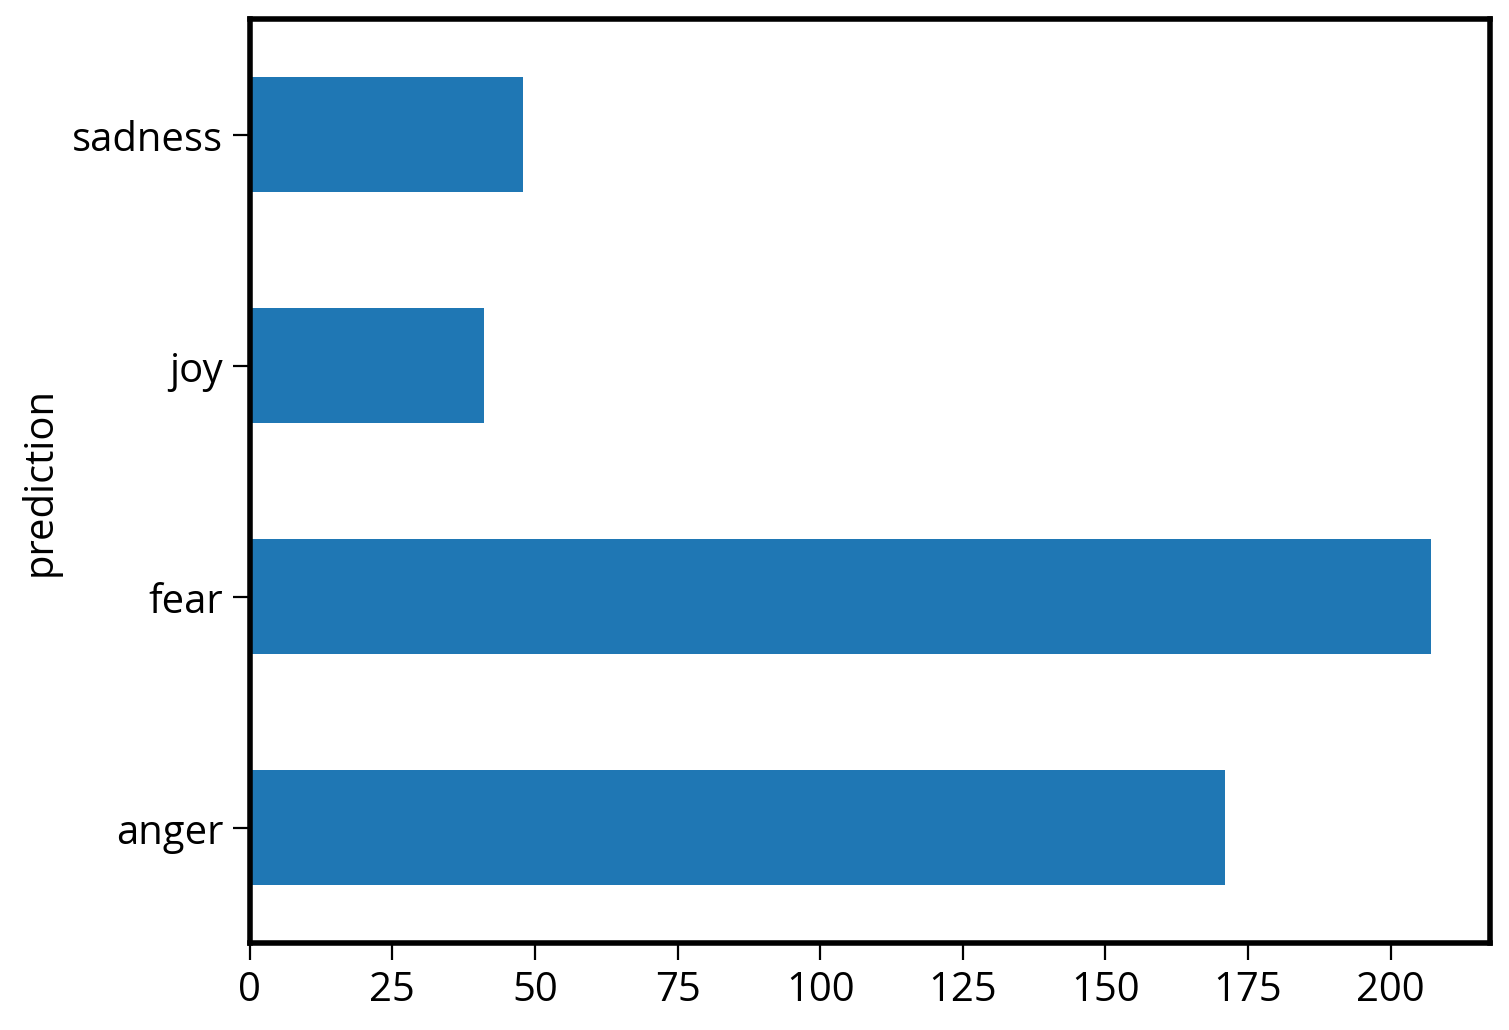

In [140]:
emotion.groupby("prediction").size().plot(kind='barh');

**Takeaway:**  Most descriptions are classified as "fear" or "anger"

How about visualizing the full distribution of scores across all emotions?

Let's get a tidy version for analysis:

In [141]:
emotion_tidy = emotion.melt(
    id_vars=["text"], value_vars=emotion_labels, var_name="emotion", value_name="score"
)

In [142]:
emotion_tidy.head()

,text,emotion,score
0,On the southwest corner of the intersection of S. 46th Street and Woodland Avenue.,anger,0.197261
1,On the 'No Dumping' street sign on the south side of Cedar Avenue about 11 steps west of S. 46th Street. Next to the tiny park.,anger,0.120488
2,Apartment complex is dumping trash on our street again! Please help or tell me the proper channels I need to take. Thank you!,anger,0.002554
3,People speed up the street like they’re all 95 it needs to have street cushions put in or speed bumps whatever you wanna call,anger,0.698201
4,This vehicle has been parked on the 5300 block of Sycamore Street. The car appears to be stolen and parts from the vehicle were removed such as Steering wheel – and other items,anger,0.133473


Make a box plot of the distribution across all emotions:

/Users/nhand/mambaforge/envs/musa-550-fall-2023/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


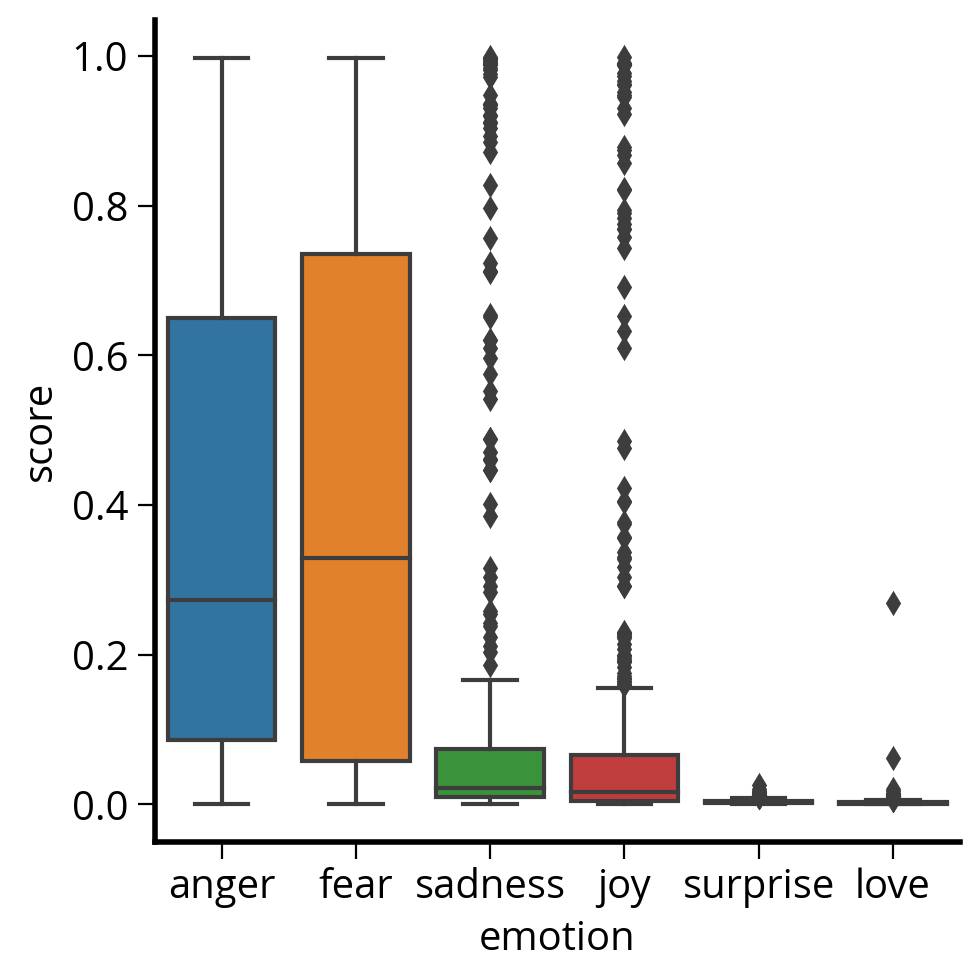

In [143]:
sns.catplot(data=emotion_tidy, x="emotion", y="score", kind="box");

**Takeaway:**

Fear and anger! For emotions other than anger/fear, confidence scores are concentrated near zero, indicating that the text likely does not contain those emotions.

Let's do a deeper dive on some of the emotions:

**Anger**

In [144]:
angry_requests = emotion.query("anger > 0.8").sort_values("anger", ascending=False)

In [145]:
len(angry_requests)

80

In [146]:
angry_requests.head(20)

,fear,anger,joy,sadness,surprise,love,text,prediction
246,0.001147,0.997735,0.000239,0.000609,0.000134,0.000136,The are rocks and other debris items that have been picked out of the trash blocking the entry and exit way to the driveway. The owner also puts some type of white chemicals on it and it has caused damage to my vehicle numerous times. There are dirty trash bags hanging along the fence area. If a resident ask her to move it she becomes very irate and combative.,anger
160,0.000773,0.996903,0.000356,0.001579,0.000128,0.000261,Hate speech on side of building on 13th and spruce,anger
132,0.001949,0.996713,0.000410,0.000497,0.000167,0.000264,Tree coming down. Very dangerous,anger
53,0.003206,0.995312,0.000421,0.000688,0.000160,0.000212,Tree coming down on Proctor Rd. Very dangerous,anger
312,0.002940,0.995312,0.000595,0.000742,0.000163,0.000248,"It is extremely hard to see at night especially since there is not stop sign on the road leading up to it. We hear cars hit it often and it is loud, sometimes flat tires happen and it’s dangerous for electric bikes and scooters.",anger
255,0.003880,0.994278,0.000740,0.000621,0.000198,0.000283,Very bad hole whole tire goes in. You can’t see it which makes it even more dangerous. It’s on the drivers side of the street. Right before the bridge. Thanks,anger
64,0.004393,0.993969,0.000550,0.000664,0.000175,0.000248,street light is out creating a dangerous area with crime in the neighborhood.,anger
61,0.004737,0.993821,0.000505,0.000447,0.000204,0.000286,View from our roof deck: looks like the back wall of their house has fallen down and into the surrounding yards and areas. Very dangerous. Homeowner attempting to put the pieces of wall back together himself. Someone go help that man!,anger
409,0.007373,0.990195,0.000709,0.001310,0.000198,0.000215,"Manton St is already a narrow street, the pothole makes trash collection difficult because the trash truck has to reverse and maneuver thru cars that are already parked on the curb, very dangerous",anger
46,0.009776,0.987523,0.000854,0.001446,0.000197,0.000205,Dangerous trash items dumped in the funeral home parking lot that was never removed properly from the past construction site at 625 Byberry Rd phila PA 19116,anger


**Fear**

And the most fearful:

In [147]:
fearful_requests = emotion.query("fear > 0.8").sort_values("fear", ascending=False)

In [148]:
len(fearful_requests)

76

In [149]:
fearful_requests.head(20)

,fear,anger,joy,sadness,surprise,love,text,prediction
38,0.997108,0.000887,0.000408,0.000987,0.000443,0.000168,"I reside next door to this vacant property. The entire back of the house is falling down. There are several squirrels, possums and raccoons hanging out of the house. There is debris falling into my backyard and my children are afraid to play back there. There are now magets falling through my sons room because I believe there is something dead in his walls. Please contact me at 267-904-1753, thank you",fear
261,0.992042,0.004499,0.000603,0.002248,0.000411,0.000196,"Open flames are being lit underneath 95 every night, which is a major fire hazard. Area has become an illegal dumping site filled with mounds of trash. Unsafe conditions with discarded needles, human waste, tents, shopping carts. Residents are afraid to walk by due to unsanitary conditions and aggressive nature of camp dwellers.",fear
203,0.991208,0.002228,0.000442,0.000383,0.005459,0.000279,"The cave-in is getting larger as time goes by. When trucks or buses go by, our whole house shakes, it is frightening.",fear
277,0.990393,0.004574,0.000967,0.003393,0.000470,0.000203,"2840 N Judson St porch is danger of collapse, held up by a board. ppl in the home dumping construction trash on the corner. Neighbors homes next door is in danger when the porch collapse too. couldn't load pic.",fear
110,0.988391,0.003221,0.001139,0.005514,0.001511,0.000224,"Missing street name sign for Cypress Street, located on the SW corner at South 9th Street.",fear
163,0.984954,0.007672,0.000770,0.005747,0.000573,0.000284,"An tenant on the second floor Clarence Young Apt 2 C has an bed bugs infestation, an refuse examination will has the other tenants, an great inconvenience we can’t used our laundry room or community room, we’re restricted from meeting in other areas, while this individual is still walking around, management can’t seem to handle the matter efficiently, his presence is everybody extremely uncomfortable , this contribute to his mental health",fear
340,0.982761,0.004817,0.001064,0.008939,0.002184,0.000234,Wrecked vehicle parked blocking crosswalk and too close to fire hydrant. Possibility of being stolen and abandoned.,fear
72,0.981407,0.010381,0.001214,0.005825,0.000919,0.000253,Property is unsealed. People are entering frequently.,fear
320,0.968219,0.008872,0.001683,0.019192,0.001595,0.000439,the fence fell on me while i was walking resulting in minor injuries.,fear
230,0.966225,0.024689,0.004373,0.003271,0.001061,0.000381,"Bulb has been out since last winter. Has been reported previously and never fixed, Not saf to walk on strett as park is very dark.",fear


**Takeaway:**

Overall, the algorithm is doing a pretty good job picking up the emotion and sentiment in the requests. 

One potential use case for a model like this: *prioritizing responses*. For example:

- You might want to respond more quickly to those that are classified as the most fearful, given that those situations might be the most dangerous. 
- Or, requests that are classified as the angriest might warrant a closer follow-up from a city representative, since many of these requests are likely repeated requests from frustrated residents.

But, once again, we see the limitations of sentiment analysis as text with words like "thank you" and "please" get classified as positive ("joy"):

In [150]:
joyful_requests = emotion.query("joy > 0.8").sort_values("joy", ascending=False)

Not that many requests!

In [151]:
len(joyful_requests)

24

In [152]:
joyful_requests.head(20)

,fear,anger,joy,sadness,surprise,love,text,prediction
218,0.000202,0.000358,0.998168,0.000476,0.000334,0.000462,vehicle hasnt ran well over a year inspection sticker in front appears to have been alter it read 11/2020 now you only see the 11 this vehicle is just taking up some valuable spot for another car that runs SO MANY VIOLATION IN THE 15TH DISTRICT THAT JUST GETTING THEY ARE SO MANY CARS IN AREA THAT ARE NOT RUNNING THEY ARE IILEGAL taking up so many spots,joy
314,0.000329,0.001318,0.990678,0.000946,0.000373,0.006355,Graffiti and sticker on sign. Please and thank you!,joy
154,0.000567,0.002886,0.989135,0.002578,0.000688,0.004146,Graffiti on entire side of building on 1850 Hope. Thank you!,joy
2,0.000414,0.002554,0.989055,0.001997,0.000243,0.005738,Apartment complex is dumping trash on our street again! Please help or tell me the proper channels I need to take. Thank you!,joy
323,0.000729,0.003696,0.988631,0.001794,0.000529,0.004622,Graffiti on sign. Please and thank you!,joy
324,0.000729,0.003696,0.988631,0.001794,0.000529,0.004622,Graffiti on sign. Please and thank you!,joy
456,0.000768,0.004943,0.988528,0.004332,0.000329,0.001101,"Hi i so a resident from 633,634,643 E Thayer st and the people from the garage on F st and Ontario st. And the beauty salon through in trash next to the electricity pole on F st. & Ontario st and they know that the pole have a sign of fine they don’t put a address in the bags because they know they can get a fine",joy
460,0.000843,0.005435,0.987868,0.004306,0.000416,0.001132,No recycle pickup yesterday for the odd numbers side of the block. All recycle bins are at the curbside waiting. Please pick up as a continued effort to keep our City clean.,joy
397,0.000218,0.000780,0.976723,0.000954,0.000370,0.020955,"The trash was not removed,the lid was off so someone obviously looked at it but decided not to put it in the truck. I've put the lid back in and would appreciate it being taken. Thanks",joy
223,0.006227,0.015431,0.973137,0.003297,0.001020,0.000887,The Calder Gardens construction site has a bright light on all night every night that shines across the entire neighborhood. I understand they need to light up the construction area but surely it doesn’t need to shine upwards into all of our bedrooms at night? It’s much brighter than any other light in the area.,joy


*Sentiment analysis* -- a helpful, but imperfect analysis tool!

## Part 2: The Census API

### US Census data is foundational

- Rich data sets with annual releases
- Decennial results plus American Community Survey (ACS) results
- Wide range of topics covered: sex, income, poverty, education, housing

### Getting census data (the new way)<br>census.data.gov

<center>
    <a href=https://data.census.gov/><img src="imgs/census-2.png" width=700></img></a>
</center>

### Example: poverty data
<center>
    <a href="https://data.census.gov/table/ACSST1Y2021.S1701?q=poverty+status&g=010XX00US$0400000&tid=ACSST1Y2021.S1701"><img src="imgs/poverty-1.png" width=900></img></a>
</center>

#### Via the API

[https://api.census.gov/data/2021/acs/acs1?get=NAME,B17001_002E&for=state:*](https://api.census.gov/data/2021/acs/acs1?get=NAME,B17001_002E&for=state:*)

- **Base endpoint:** https://api.census.gov/data/2021/acs/acs1
- **Request parameters:** "get", "for"

![](imgs/poverty-2.png)

### How to find the right variable names?

The census provides web-based documentation:

- Overview of all data tables: [https://api.census.gov/data.html](https://api.census.gov/data.html)
- All data tables for 2021: [https://api.census.gov/data/2021.html](https://api.census.gov/data/2021.html)
- All variables for 2021 ACS 5-year data set: [https://api.census.gov/data/2021/acs/acs5/variables.html](https://api.census.gov/data/2021/acs/acs5/variables.html)

### A detailed Census API guide

[https://www.census.gov/data/developers/guidance/api-user-guide.html](https://www.census.gov/data/developers/guidance/api-user-guide.html)

### Accessing the API is easier from Python

Several packages provide easier Python interfaces to census data based on the census API.

We'll focus on **`cenpy` - "Explore and download data from Census APIs"**
 - [Documentation](https://cenpy-devs.github.io/cenpy/)
 - [GitHub](https://github.com/cenpy-devs/cenpy)

### Example: the racial "dot" map

![](imgs/racial-dot-map.png)

Source: [Washington Post](https://www.washingtonpost.com/graphics/2018/national/segregation-us-cities/)

Let's make this for Philadelphia in Python!

In [4]:
# !pip install cenpy

In [58]:
# First step: import cenpy
import cenpy

/opt/anaconda3/envs/geospatial/lib/python3.10/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


#### The "explorer" module

Functions to help you explore the Census API from Python

- [`cenpy.explorer.available`](https://cenpy-devs.github.io/cenpy/generated/cenpy.explorer.available.html#cenpy.explorer.available): Returns information about available datasets in Census API
- [`cenpy.explorer.explain`](https://cenpy-devs.github.io/cenpy/generated/cenpy.explorer.explain.html#cenpy.explorer.explain): Explain a specific Census dataset
- [`cenpy.explorer.fips_table`](https://cenpy-devs.github.io/cenpy/generated/cenpy.explorer.fips_table.html#cenpy.explorer.fips_table): Get a table of FIPS codes for a specific geography

**Note: we can change pandas display options to see all rows/columns and large cells**

In [6]:
# UNCOMMENT TO SEE ALL ROWS/COLUMNS IN DATAFRAMES
# pd.options.display.max_rows = 9999 
# pd.options.display.max_colwidth = 200

#### Step 1: Identify what dataset we want

- Today, we'll use the 5-year American Community Survey (latest available year: 2021)
- Other common datasets: 
    - 1-year ACS datasets as well (latest available year: 2022)
    - 10-year decennial survey (latest available year: 2020)

In [62]:
import cenpy
available = cenpy.explorer.available()

# available.head()

/opt/anaconda3/envs/geospatial/lib/python3.10/site-packages/cenpy/explorer.py:70: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  listcols = raw_table.applymap(lambda x: isinstance(x, list)).any()


We can use the pandas [`filter()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.filter.html) to search for specific identifiers in the dataframe. 

In this case, let's search for the American Community Survey datasets. We'll match index labels using *regular expressions*. 

In particular, we'll search for labels that start with "ACS". In the language of regular expressions, we'll use the "^" to mean "match labels that start with"

For more info on regular expressions, the [documentation for the re module](https://docs.python.org/3/library/re.html) is a good place to start.

In [63]:
# Return a dataframe of all datasets that start with "ACS"
# Axis=0 means to filter the index labels!
acs = available.filter(regex="^ACS", axis=0)

# acs

Many flavors of ACS datasets are available — we want to use the *detailed tables* version, specifically the 5-year survey. 

The relevant identifiers start with: "ACSDT5Y".

In [61]:
# Return a dataframe of all datasets that start with "ACSDT5Y"
available.filter(regex="^ACSDT5Y", axis=0)

,c_isTimeseries,temporal,spatial,c_isAggregate,publisher,references,programCode,modified,license,keyword,identifier_url,contactPoint,distribution,description,bureauCode,accessLevel,title,c_isAvailable,c_isCube,c_isMicrodata,c_documentationLink,c_dataset,vintage
ACSDT5Y2009,NaN,NaN,NaN,True,U.S. Census Bureau,https://www.census.gov/developers/,006:004,2019-08-27 13:11:18.0,https://creativecommons.org/publicdomain/zero/1.0/,"(census,)",https://api.census.gov/data/id/ACSDT5Y2009,"{'fn': 'American Community Survey Office', 'hasEmail': 'mailto:acso.users.support@census.gov'}","{'@type': 'dcat:Distribution', 'accessURL': 'http://api.census.gov/data/2009/acs/acs5', 'description': 'API endpoint', 'format': 'API', 'mediaType': 'application/json', 'title': 'API endpoint'}","The American Community Survey (ACS) is an ongoing survey that provides data every year -- giving communities the current information they need to plan investments and services. The ACS covers a broad range of topics about social, economic, demographic, and housing characteristics of the U.S. population. Summary files include the following geographies: nation, all states (including DC and Puerto Rico), all metropolitan areas, all congressional districts (114th congress), all counties, all places, and all tracts and block groups. Summary files contain the most detailed cross-tabulations, many of which are published down to block groups. The data are population and housing counts. There are over 64,000 variables in this dataset.",006:07,public,American Community Survey: 5-Year Estimates: Detailed Tables 5-Year,True,True,NaN,https://www.census.gov/developer/,"(acs, acs5)",2009.0
ACSDT5Y2010,NaN,NaN,United States,True,U.S. Census Bureau,https://www.census.gov/developers/,006:004,2018-07-04 00:00:00.0,https://creativecommons.org/publicdomain/zero/1.0/,"(census,)",https://api.census.gov/data/id/ACSDT5Y2010,"{'fn': 'American Community Survey Office', 'hasEmail': 'mailto:acso.users.support@census.gov'}","{'@type': 'dcat:Distribution', 'accessURL': 'http://api.census.gov/data/2010/acs/acs5', 'description': 'API endpoint', 'format': 'API', 'mediaType': 'application/json', 'title': 'API endpoint'}","The American Community Survey (ACS) is an ongoing survey that provides data every year -- giving communities the current information they need to plan investments and services. The ACS covers a broad range of topics about social, economic, demographic, and housing characteristics of the U.S. population. Summary files include the following geographies: nation, all states (including DC and Puerto Rico), all metropolitan areas, all congressional districts (114th congress), all counties, all places, and all tracts and block groups. Summary files contain the most detailed cross-tabulations, many of which are published down to block groups. The data are population and housing counts. There are over 64,000 variables in this dataset.",006:07,public,ACS 5-Year Detailed Tables,True,True,NaN,https://www.census.gov/developer/,"(acs, acs5)",2010.0
ACSDT5Y2011,NaN,NaN,NaN,True,U.S. Census Bureau,https://www.census.gov/developers/,006:004,2018-07-04 00:00:00.0,https://creativecommons.org/publicdomain/zero/1.0/,"(census,)",https://api.census.gov/data/id/ACSDT5Y2011,"{'fn': 'American Community Survey Office', 'hasEmail': 'mailto:acso.users.support@census.gov'}","{'@type': 'dcat:Distribution', 'accessURL': 'http://api.census.gov/data/2011/acs/acs5', 'description': 'API endpoint', 'format': 'API', 'mediaType': 'application/json', 'title': 'API endpoint'}","The American Community Survey (ACS) is an ongoing survey that provides data every year -- giving communities the current information they need to plan investments and services. The ACS covers a broad range of topics about social, economic, demographic, and housing characteristics of the U.S. population. Summary files include the following geographies: nation, all states (including DC and Puerto Rico), all metropolitan areas, all congressional distric

Let's use the latest available 5-year data (2021). We can use the `explain()` function to print out a description of the dataset:

In [64]:
import cenpy
cenpy.explorer.explain("ACSDT5Y2021")

{'American Community Survey: 5-Year Estimates: Detailed Tables 5-Year': 'The American Community Survey (ACS) is an ongoing survey that provides data every year -- giving communities the current information they need to plan investments and services. The ACS covers a broad range of topics about social, economic, demographic, and housing characteristics of the U.S. population. Summary files include the following geographies: nation, all states (including DC and Puerto Rico), all metropolitan areas, all congressional districts, all counties, all places, and all tracts and block groups. Summary files contain the most detailed cross-tabulations, many of which are published down to block groups. The data are population and housing counts. There are over 64,000 variables in this dataset.'}

#### Step 2: Initialize the API connection

Use the `cenpy.remote.APIConnection` object, and pass it the name of the dataset.

In [65]:
acs = cenpy.remote.APIConnection("ACSDT5Y2021")

#### Step 3: Find the variables we want to load

The `.variables` attribute stores the available variables (across all Census tables). 

We can use the `varslike()` function to search the `variables` dataframe (it's just a simple wrapper around the pandas `filter()` function).

In [66]:
len(acs.variables)

27927

In [67]:
acs.variables.head(n=5)

,label,concept,predicateType,group,limit,predicateOnly,hasGeoCollectionSupport,attributes,required
for,Census API FIPS 'for' clause,Census API Geography Specification,fips-for,N/A,0,True,NaN,NaN,NaN
in,Census API FIPS 'in' clause,Census API Geography Specification,fips-in,N/A,0,True,NaN,NaN,NaN
ucgid,Uniform Census Geography Identifier clause,Census API Geography Specification,ucgid,N/A,0,True,True,NaN,NaN
B24022_060E,Estimate!!Total:!!Female:!!Service occupations:!!Food preparation and serving related occupations,"SEX BY OCCUPATION AND MEDIAN EARNINGS IN THE PAST 12 MONTHS (IN 2021 INFLATION-ADJUSTED DOLLARS) FOR THE FULL-TIME, YEAR-ROUND CIVILIAN EMPLOYED POPULATION 16 YEARS AND OVER",int,B24022,0,NaN,NaN,"B24022_060EA,B24022_060M,B24022_060MA",NaN
B19001B_014E,"Estimate!!Total:!!$100,000 to $124,999",HOUSEHOLD INCOME IN THE PAST 12 MONTHS (IN 2021 INFLATION-ADJUSTED DOLLARS) (BLACK OR AFRICAN AMERICAN ALONE HOUSEHOLDER),int,B19001B,0,NaN,NaN,"B19001B_014EA,B19001B_014M,B19001B_014MA",NaN


We're interested in variables about hispanic origin broken down by race — let's see if we can find the variables where the "Concept" column starts with "RACE"

In [162]:
acs.varslike?

Signature: acs.varslike(pattern=None, by=None, engine='re', within=None)
Docstring:
Grabs columns that match a particular search pattern.

Parameters
----------
pattern : str
          a search pattern to match
by      : str
          a column in the APIConnection.variables to conduct the search
          within
engine  : {'re', 'fnmatch', callable}
          backend string matching module to use, or a function of the form
          match(candidate, pattern). (default: 're')
within  : pandas.DataFrame 
          the variables over which to search.

Notes
------
Only regex and fnmatch will be supported modules. Note that, while
regex is the default, the python regular expressions module has some
strange behavior if you're used to VIM or Perl-like regex. It may be
easier to use fnmatch if regex is not providing the results you expect.

If you want, you can also pass an engine that is a function. If so, this
needs to be a function that has a signature like:

fn(candidate, pattern)

and re

In [68]:
race_matches = acs.varslike(
    pattern="HISPANIC OR LATINO ORIGIN BY RACE",
    by="concept",  # searches along concept column
).sort_index()


In [69]:
race_matches

,label,concept,predicateType,group,limit,predicateOnly,hasGeoCollectionSupport,attributes,required
B03002_001E,Estimate!!Total:,HISPANIC OR LATINO ORIGIN BY RACE,int,B03002,0,NaN,NaN,"B03002_001EA,B03002_001M,B03002_001MA",NaN
B03002_002E,Estimate!!Total:!!Not Hispanic or Latino:,HISPANIC OR LATINO ORIGIN BY RACE,int,B03002,0,NaN,NaN,"B03002_002EA,B03002_002M,B03002_002MA",NaN
B03002_003E,Estimate!!Total:!!Not Hispanic or Latino:!!White alone,HISPANIC OR LATINO ORIGIN BY RACE,int,B03002,0,NaN,NaN,"B03002_003EA,B03002_003M,B03002_003MA",NaN
B03002_004E,Estimate!!Total:!!Not Hispanic or Latino:!!Black or African American alone,HISPANIC OR LATINO ORIGIN BY RACE,int,B03002,0,NaN,NaN,"B03002_004EA,B03002_004M,B03002_004MA",NaN
B03002_005E,Estimate!!Total:!!Not Hispanic or Latino:!!American Indian and Alaska Native alone,HISPANIC OR LATINO ORIGIN BY RACE,int,B03002,0,NaN,NaN,"B03002_005EA,B03002_005M,B03002_005MA",NaN
B03002_006E,Estimate!!Total:!!Not Hispanic or Latino:!!Asian alone,HISPANIC OR LATINO ORIGIN BY RACE,int,B03002,0,NaN,NaN,"B03002_006EA,B03002_006M,B03002_006MA",NaN
B03002_007E,Estimate!!Total:!!Not Hispanic or Latino:!!Native Hawaiian and Other Pacific Islander alone,HISPANIC OR LATINO ORIGIN BY RACE,int,B03002,0,NaN,NaN,"B03002_007EA,B03002_007M,B03002_007MA",NaN
B03002_008E,Estimate!!Total:!!Not Hispanic or Latino:!!Some other race alone,HISPANIC OR LATINO ORIGIN BY RACE,int,B03002,0,NaN,NaN,"B03002_008EA,B03002_008M,B03002_008MA",NaN
B03002_009E,Estimate!!Total:!!Not Hispanic or Latino:!!Two or more races:,HISPANIC OR LATINO ORIGIN BY RACE,int,B03002,0,NaN,NaN,"B03002_009EA,B03002_009M,B03002_009MA",NaN
B03002_010E,Estimate!!Total:!!Not Hispanic or Latino:!!Two or more races:!!Two races including Some other race,HISPANIC OR LATINO ORIGIN BY RACE,int,B03002,0,NaN,NaN,"B03002_010EA,B03002_010M,B03002_010MA",NaN


It looks like the table we want is "B03002" — we can also easily filter for all variables in this table

In [76]:
variables = [
    "NAME",
    "B03002_001E", # Total
    "B03002_003E", # Not Hispanic, White
    "B03002_004E", # Not Hispanic, Black
    "B03002_005E", # Not Hispanic, American Indian
    "B03002_006E", # Not Hispanic, Asian
    "B03002_007E", # Not Hispanic, Native Hawaiian
    "B03002_008E", # Not Hispanic, Other
    "B03002_009E", # Not Hispanic, Two or More Races
    "B03002_012E", # Hispanic
]

::: {.callout-note}
We've also include the "NAME" variable which returns the name of the Census geography we are querying for.
:::

#### Step 4: Identify the geographies to use

The Census API use heirarchy of geographies when requesting data.

For example, you cannot just request data for a specific county — you need to specify the state *and* the county.

<img src="imgs/census-hierarchy.png" width=700></img>

**Common hierarchies**

- State --> county
- State --> place (e.g., cities)
- State --> county --> tract
- State --> county --> tract --> block group

**Tip:** Use the `.geographies` attribute

This allows you to see:

1. What geographies are available for a specific dataset
1. The other required geographies in the heirarchy

In [77]:
acs

Connection to American Community Survey: 5-Year Estimates: Detailed Tables 5-Year (ID: https://api.census.gov/data/id/ACSDT5Y2021)

In [78]:
# acs.geographies['fips']

For the racial dot map, we'll use the most granular available geography: block group.

The hierarchy is: state --> county --> tract --> block group but we can use the `*` operator for tracts so we'll need to know the **FIPS codes for PA and Philadelphia County**

In [79]:
counties = cenpy.explorer.fips_table("COUNTY")
counties.head()

,0,1,2,3,4
0,AL,1,1,Autauga County,H1
1,AL,1,3,Baldwin County,H1
2,AL,1,5,Barbour County,H1
3,AL,1,7,Bibb County,H1
4,AL,1,9,Blount County,H1


In [80]:
# Trim to just Philadelphia
# Search for rows where name contains "Philadelphia"
counties.loc[ counties[3].str.contains("Philadelphia") ]

,0,1,2,3,4
2294,PA,42,101,Philadelphia County,H6


For Philadelphia County, the FIPS codes are:

- Philadelphia County: "101" 
- PA: "42"

In [81]:
philly_county_code = "101"
pa_state_code = "42"

You can also look up FIPS codes on Google! Wikipedia is usually a trustworthy source...

#### Step 5: Build the query (finally)

We'll use the `.query()` function, which takes the following arguments:

1. `cols` - the list of variables desired from the dataset
1. `geo_unit` - string denoting the smallest geographic unit; syntax is "name:FIPS"
1. `geo_filter` - dictionary containing groupings of geo_units, if required by the hierarchy


In [82]:
philly_demo_data = acs.query(
    cols=variables,
    geo_unit="block group:*",
    geo_filter={"state": pa_state_code, "county": philly_county_code, "tract": "*"},
)


philly_demo_data.head()

,NAME,B03002_001E,B03002_003E,B03002_004E,B03002_005E,B03002_006E,B03002_007E,B03002_008E,B03002_009E,B03002_012E,state,county,tract,block group
0,"Block Group 1, Census Tract 1.01, Philadelphia County, Pennsylvania",0,0,0,0,0,0,0,0,0,42,101,000101,1
1,"Block Group 2, Census Tract 1.01, Philadelphia County, Pennsylvania",0,0,0,0,0,0,0,0,0,42,101,000101,2
2,"Block Group 3, Census Tract 1.01, Philadelphia County, Pennsylvania",0,0,0,0,0,0,0,0,0,42,101,000101,3
3,"Block Group 4, Census Tract 1.01, Philadelphia County, Pennsylvania",1129,770,11,0,88,0,0,37,223,42,101,000101,4
4,"Block Group 5, Census Tract 1.01, Philadelphia County, Pennsylvania",875,683,0,0,69,0,0,0,123,42,101,000101,5


In [83]:
len(philly_demo_data)

1338

**Important:** data is returned as strings rather than numeric values

In [84]:
for variable in variables:
    # Convert all variables EXCEPT for NAME
    if variable != "NAME":
        philly_demo_data[variable] = philly_demo_data[variable].astype(float)

**What if we mess up the geographic hierarchy?**

If you forget to include required parts of the geography heirarchy, you'll get an error!

In [86]:
pa_state_code

'42'

In [88]:
acs.query(
    cols=variables,
    geo_unit="block group:*",
    geo_filter={"state": pa_state_code, "county": "*", "tract": "*"},
)

,NAME,B03002_001E,B03002_003E,B03002_004E,B03002_005E,B03002_006E,B03002_007E,B03002_008E,B03002_009E,B03002_012E,state,county,tract,block group
0,"Block Group 1, Census Tract 301.01, Adams County, Pennsylvania",958,780,47,0,1,0,0,4,126,42,001,030101,1
1,"Block Group 2, Census Tract 301.01, Adams County, Pennsylvania",1691,1502,0,0,1,0,8,74,106,42,001,030101,2
2,"Block Group 1, Census Tract 301.03, Adams County, Pennsylvania",2268,2258,0,0,0,0,0,10,0,42,001,030103,1
3,"Block Group 1, Census Tract 301.04, Adams County, Pennsylvania",1066,1060,0,0,0,0,0,6,0,42,001,030104,1
4,"Block Group 2, Census Tract 301.04, Adams County, Pennsylvania",2447,2277,0,0,0,0,0,71,99,42,001,030104,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10168,"Block Group 2, Census Tract 240.01, York County, Pennsylvania",2210,2131,40,15,0,0,0,24,0,42,133,024001,2
10169,"Block Group 3, Census Tract 240.01, York County, Pennsylvania",656,656,0,0,0,0,0,0,0,42,133,024001,3
10170,"Block Group 4, Census Tract 240.01, York County, Pennsylvania",534,472,0,0,0,0,0,14,48,42,133,024001,4
10171,"Block Group 1, Census Tract 240.02, York County, Pennsylvania",2245,2182,0,0,12,0,0,41,10,42,133,024002,1


#### Step 6: We need the block group geometries too!

Use the [`pygris` package](https://walker-data.com/pygris/) to download geometries. It's a port of the R package `tigris` to Python!

In [91]:
# !pip install pygris

In [92]:
import pygris

There's a function to return each of the main Census geographies. We'll use the `block_groups()` function.

In [176]:
pygris.block_groups?

Signature:
pygris.block_groups(
    state=None,
    county=None,
    cb=False,
    year=None,
    cache=False,
    subset_by=None,
)
Docstring:
 Load a Census block groups shapefile into Python as a GeoDataFrame

Parameters
----------
state : str 
    The state name, state abbreviation, or two-digit FIPS code of the desired state. 
    If None, block groups for the entire United States will be downloaded if 
    available for that year / dataset combination.  
county : str
    The county name or three-digit FIPS code of the desired county. If None, block groups
    for the selected state will be downloaded. 
cb : bool 
    If set to True, download a generalized (1:500k) cartographic boundary file.  
    Defaults to False (the regular TIGER/Line file).
year : int 
    The year of the TIGER/Line or cartographic boundary shapefile. 
cache : bool 
    If True, the function will download a Census shapefile to a cache directory 
    on the user's computer for future access.  If False, the fu

In [93]:
philly_block_groups = pygris.block_groups(
    state=pa_state_code, county=philly_county_code, year=2021
)

In [94]:
philly_block_groups.head()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
124,42,101,989100,2,421019891002,Block Group 2,G5030,S,373653,7060,+40.0373207,-075.0177378,"POLYGON ((-75.02195 40.03435, -75.02191 40.03451, -75.02173 40.03482, -75.02151 40.03515, -75.02135 40.03544, -75.02129 40.03562, -75.0213 40.03582, -75.02134 40.03607, -75.0215 40.03638, -75.02163 40.03663, -75.02181 40.03702, -75.02168 40.03709, -75.01967 40.03812, -75.01902 40.03847, -75.01843 40.03877, -75.01783 40.03908, -75.01703 40.0395, -75.01621 40.03991, -75.01535 40.03894, -75.015 40.0391, -75.01432 40.03945, -75.01254 40.03803, -75.01216 40.03772, -75.01195 40.03755, -75.01131 40.03704, -75.01225 40.03654, -75.0153 40.03485, -75.0179 40.0334, -75.01797 40.03336, -75.01818 40.0335, -75.01862 40.03366, -75.0196 40.03374, -75.01986 40.03376, -75.02 40.03377, -75.02011 40.03378, -75.02022 40.03378, -75.02042 40.03379, -75.02082 40.03378, -75.02126 40.03374, -75.02142 40.03375, -75.02157 40.03381, -75.02172 40.03392, -75.0218 40.03401, -75.02189 40.03411, -75.02195 40.03422, -75.02195 40.03435))"
125,42,101,989100,4,421019891004,Block Group 4,G5030,S,1399991,948653,+40.0407424,-074.9975532,"POLYGON ((-75.01254 40.03803, -75.01195 40.03824, -75.01165 40.03836, -75.01134 40.03848, -75.01104 40.0386, -75.01074 40.03873, -75.01045 40.03887, -75.01016 40.03901, -75.0101 40.03904, -75.00987 40.03915, -75.00958 40.0393, -75.00943 40.03938, -75.00901 40.03959, -75.00873 40.03973, -75.00844 40.03988, -75.00817 40.04003, -75.00789 40.04019, -75.00735 40.04051, -75.00681 40.04084, -75.00654 40.041, -75.00628 40.04116, -75.00519 40.04181, -75.00351 40.04282, -75.00297 40.04315, -75.00062 40.04458, -75.00035 40.04474, -75.00008 40.0449, -74.99981 40.04507, -74.99954 40.04523, -74.99874 40.04572, -74.99712 40.04669, -74.99631 40.04718, -74.99627 40.0472, -74.9954 40.04644, -74.99472 40.04584, -74.9941 40.0453, -74.99382 40.04504, -74.99349 40.04476, -74.9932 40.04449, -74.99288 40.04421, -74.99227 40.04368, -74.99166 40.04313, -74.99098 40.04253, -74.99094 40.04252, -74.9906 40.04237, -74.9903 40.04238, -74.98657 40.03896, -74.98764 40.03819, -74.99007 40.03644, -74.99409 40.03341, -74.9953 40.03257, -74.9962 40.03193, -74.99711 40.03129, -74.99816 40.03051, -75.00062 40.0287, -75.00198 40.02798, -75.00335 40.02726, -75.00546 40.0311, -75.00533 40.03118, -75.00522 40.03126, -75.00508 40.03134, -75.00498 40.03143, -75.00487 40.03151, -75.00471 40.03168, -75.00465 40.03178, -75.00457 40.03187, -75.00455 40.03191, -75.00456 40.03194, -75.00464 40.03202, -75.00473 40.03207, -75.00485 40.03212, -75.00497 40.03215, -75.00508 40.03216, -75.00519 40.03215, -75.00529 40.03214, -75.00548 40.03212, -75.00559 40.0321, -75.0057 40.03205, -75.00582 40.03204, -75.00592 40.03204, -75.0061 40.0322, -75.00621 40.03219, -75.00651 40.03233, -75.00694 40.03258, -75.00729 40.03289, -75.00741 40.03309, -75.00741 40.0333, -75.00728 40.03375, -75.00722 40.03412, -75.00726 40.03439, -75.00739 40.03471, -75.00766 40.03505, -75.00795 40.03534, -75.00818 40.03551, -75.0086 40.03557, -75.00928 40.03547, -75.01001 40.03522, -75.01076 40.03475, -75.01106 40.0345, -75.01119 40.03464, -75.01122 40.03471, -75.01128 40.03479, -75.0114 40.03491, -75.01148 40.03496, -75.01159 40.03503, -75.01178 40.03514, -75.01181 40.03518, -75.01222 40.03553, -75.01196 40.03621, -75.01225 40.03654, -75.01131 40.03704, -75.01195 40.03755, -75.01216 40.03772, -75.01254 40.03803))"
126,42,101,989100,3,421019891003,Block Group 3,G5030,S,820212,566882,+40.0297287,-075.0119000,"POLYGON ((-75.02251 40.03083, -75.02176 40.03124, -75.02157 40.03135, -75.02127 40.03152, -75.02056 40.03192, -75.01994 40.03226, -75.01984 40.03232, -75.01814 40.03327, -75.01805 40.03332, -75.01797 40.03336, -75.01787 40.03329, -75.0171 40.0327, -75.01666 40.03231, -75.01632 40.0319, -75.01611 40.03154, -75.01586 40.03125, -75.01558 40.03106, -75.01505 40.03085, -75.01464 40.03074, -75.0143 40.0307, -75.01382 40.03072, -7

In [95]:
len(philly_block_groups)

1338

#### Step 7: Merge the demographic data with geometries

Merge based on multiple columns: state, county, tract, and block group IDs.

The relevant columns are: 

- "STATEFP", "COUNTYFP", "TRACTCE", "BLKGRCE" in the spatial data
- "state", "county", "tract", "block group" in the non-spatial data

In [96]:
philly_demo_final = philly_block_groups.merge(
    philly_demo_data,
    left_on=["STATEFP", "COUNTYFP", "TRACTCE", "BLKGRPCE"],
    right_on=["state", "county", "tract", "block group"],
)

In [97]:
philly_demo_final.head()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,NAME,B03002_001E,B03002_003E,B03002_004E,B03002_005E,B03002_006E,B03002_007E,B03002_008E,B03002_009E,B03002_012E,state,county,tract,block group
0,42,101,989100,2,421019891002,Block Group 2,G5030,S,373653,7060,+40.0373207,-075.0177378,"POLYGON ((-75.02195 40.03435, -75.02191 40.03451, -75.02173 40.03482, -75.02151 40.03515, -75.02135 40.03544, -75.02129 40.03562, -75.0213 40.03582, -75.02134 40.03607, -75.0215 40.03638, -75.02163 40.03663, -75.02181 40.03702, -75.02168 40.03709, -75.01967 40.03812, -75.01902 40.03847, -75.01843 40.03877, -75.01783 40.03908, -75.01703 40.0395, -75.01621 40.03991, -75.01535 40.03894, -75.015 40.0391, -75.01432 40.03945, -75.01254 40.03803, -75.01216 40.03772, -75.01195 40.03755, -75.01131 40.03704, -75.01225 40.03654, -75.0153 40.03485, -75.0179 40.0334, -75.01797 40.03336, -75.01818 40.0335, -75.01862 40.03366, -75.0196 40.03374, -75.01986 40.03376, -75.02 40.03377, -75.02011 40.03378, -75.02022 40.03378, -75.02042 40.03379, -75.02082 40.03378, -75.02126 40.03374, -75.02142 40.03375, -75.02157 40.03381, -75.02172 40.03392, -75.0218 40.03401, -75.02189 40.03411, -75.02195 40.03422, -75.02195 40.03435))","Block Group 2, Census Tract 9891, Philadelphia County, Pennsylvania",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,42,101,989100,2
1,42,101,989100,4,421019891004,Block Group 4,G5030,S,1399991,948653,+40.0407424,-074.9975532,"POLYGON ((-75.01254 40.03803, -75.01195 40.03824, -75.01165 40.03836, -75.01134 40.03848, -75.01104 40.0386, -75.01074 40.03873, -75.01045 40.03887, -75.01016 40.03901, -75.0101 40.03904, -75.00987 40.03915, -75.00958 40.0393, -75.00943 40.03938, -75.00901 40.03959, -75.00873 40.03973, -75.00844 40.03988, -75.00817 40.04003, -75.00789 40.04019, -75.00735 40.04051, -75.00681 40.04084, -75.00654 40.041, -75.00628 40.04116, -75.00519 40.04181, -75.00351 40.04282, -75.00297 40.04315, -75.00062 40.04458, -75.00035 40.04474, -75.00008 40.0449, -74.99981 40.04507, -74.99954 40.04523, -74.99874 40.04572, -74.99712 40.04669, -74.99631 40.04718, -74.99627 40.0472, -74.9954 40.04644, -74.99472 40.04584, -74.9941 40.0453, -74.99382 40.04504, -74.99349 40.04476, -74.9932 40.04449, -74.99288 40.04421, -74.99227 40.04368, -74.99166 40.04313, -74.99098 40.04253, -74.99094 40.04252, -74.9906 40.04237, -74.9903 40.04238, -74.98657 40.03896, -74.98764 40.03819, -74.99007 40.03644, -74.99409 40.03341, -74.9953 40.03257, -74.9962 40.03193, -74.99711 40.03129, -74.99816 40.03051, -75.00062 40.0287, -75.00198 40.02798, -75.00335 40.02726, -75.00546 40.0311, -75.00533 40.03118, -75.00522 40.03126, -75.00508 40.03134, -75.00498 40.03143, -75.00487 40.03151, -75.00471 40.03168, -75.00465 40.03178, -75.00457 40.03187, -75.00455 40.03191, -75.00456 40.03194, -75.00464 40.03202, -75.00473 40.03207, -75.00485 40.03212, -75.00497 40.03215, -75.00508 40.03216, -75.00519 40.03215, -75.00529 40.03214, -75.00548 40.03212, -75.00559 40.0321, -75.0057 40.03205, -75.00582 40.03204, -75.00592 40.03204, -75.0061 40.0322, -75.00621 40.03219, -75.00651 40.03233, -75.00694 40.03258, -75.00729 40.03289, -75.00741 40.03309, -75.00741 40.0333, -75.00728 40.03375, -75.00722 40.03412, -75.00726 40.03439, -75.00739 40.03471, -75.00766 40.03505, -75.00795 40.03534, -75.00818 40.03551, -75.0086 40.03557, -75.00928 40.03547, -75.01001 40.03522, -75.01076 40.03475, -75.01106 40.0345, -75.01119 40.03464, -75.01122 40.03471, -75.01128 40.03479, -75.0114 40.03491, -75.01148 40.03496, -75.01159 40.03503, -75.01178 40.03514, -75.01181 40.03518, -75.01222 40.03553, -75.01196 40.03621, -75.01225 40.03654, -75.01131 40.03704, -75.01195 40.03755, -75.01216 40.03772, -75.01254 40.03803))","Block Group 4, Census Tract 9891, Philadelphia County, Pennsylvania",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,42,101,989100,4
2,42,101,989100,3,421019891003,Block Group 3,G5030,S,820212,566882,+40.0297287,-075.0119000,"POLYGON ((-75.02251 40.03083, -75.02176 40.03

**We're done! Plot it to make sure it makes sense**

Plot the total population using `geopandas.explore()`...

In [98]:
philly_demo_final.explore(column="B03002_001E", tiles="CartoDB positron")

#### Now let's prep the data for the dot map

1. Rename columns to more user-friendly versions
1. Add a general "Other" category

In [99]:
# Rename columns
philly_demo_final = philly_demo_final.rename(
    columns={
        "B03002_001E": "Total",  # Total
        "B03002_003E": "White",  # Not Hispanic, White
        "B03002_004E": "Black",  # Not Hispanic, Black
        "B03002_005E": "AI/AN",  # Not Hispanic, American Indian
        "B03002_006E": "Asian",  # Not Hispanic, Asian
        "B03002_007E": "NH/PI",  # Not Hispanic, Native Hawaiian
        "B03002_008E": "Other_",  # Not Hispanic, Other
        "B03002_009E": "Two Plus",  # Not Hispanic, Two or More Races
        "B03002_012E": "Hispanic",  # Hispanic
    }
)

In [100]:
# Add an "Other" column 
cols = ['AI/AN', 'NH/PI','Other_', 'Two Plus']
philly_demo_final['Other'] = philly_demo_final[cols].sum(axis=1)

#### Define a function to create random points

Given a polygon, create randomly distributed points that fall within the polygon.

In [101]:
from shapely.geometry import Point

In [102]:
def random_points_in_polygon(number, polygon):
    """
    Generate a random number of points within the 
    specified polygon.
    """
    points = []
    min_x, min_y, max_x, max_y = polygon.bounds
    i= 0
    while i < number:
        point = Point(np.random.uniform(min_x, max_x), np.random.uniform(min_y, max_y))
        if polygon.contains(point):
            points.append(point)
            i += 1
    return points


**Random points example**

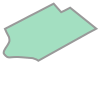

In [103]:
# get the first block group polygon in the data set
geo = philly_demo_final.iloc[0].geometry

geo

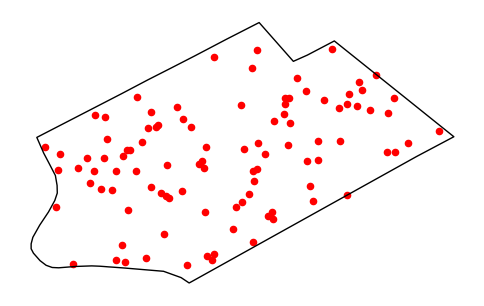

In [104]:
fig, ax = plt.subplots(figsize=(6, 6))

# Generate some random points
random_points = random_points_in_polygon(100, geo)

# Plot random points
gpd.GeoSeries(random_points).plot(ax=ax, markersize=20, color="red")

# Plot boundary of block group
gpd.GeoSeries([geo]).plot(ax=ax, facecolor="none", edgecolor="black")

ax.set_axis_off()

In [105]:
def generate_dot_map(data, people_per_dot):
    """
    Given a GeoDataFrame with demographic columns, generate a dot 
    map according to the population in each geometry.
    """
    results = []
    for field in ["White", "Hispanic", "Black", "Asian", "Other"]:

        # generate random points
        pts = data.apply(
            lambda row: random_points_in_polygon(
                row[field] / people_per_dot, row["geometry"]
            ),
            axis=1,
        )

        # combine into single GeoSeries
        pts = gpd.GeoSeries(pts.apply(pd.Series).stack(), dtype=object, crs=data["geometry"].crs)
        pts.name = "geometry"

        # make into a GeoDataFrame
        pts = gpd.GeoDataFrame(pts)
        pts["field"] = field

        # save
        results.append(pts)

    return gpd.GeoDataFrame(pd.concat(results), crs=data["geometry"].crs).reset_index(
        drop=True
    )

#### Calculate the dot map

In [106]:
dot_map = generate_dot_map(philly_demo_final, people_per_dot=50)

In [107]:
print("number of points = ", len(dot_map))

number of points =  34470


In [108]:
dot_map.tail()

,geometry,field
34465,POINT (-75.23359 40.06434),Other
34466,POINT (-75.23696 40.06569),Other
34467,POINT (-75.07941 40.03529),Other
34468,POINT (-75.07869 40.03478),Other
34469,POINT (-75.07948 40.03503),Other


#### Now let's plot it

In [109]:
# setup a custom color map from ColorBrewer
from matplotlib.colors import ListedColormap


colors = {
    "Black": "steelblue",
    "White": "tomato",
    "Hispanic": "khaki",
    "Asian": "palegreen",
    "Other": "darkgray",
}

cmap = ListedColormap([t[1] for t in sorted(colors.items())])

In [110]:
# Convert to 3857
dot_map_3857 = dot_map.to_crs(epsg=3857)

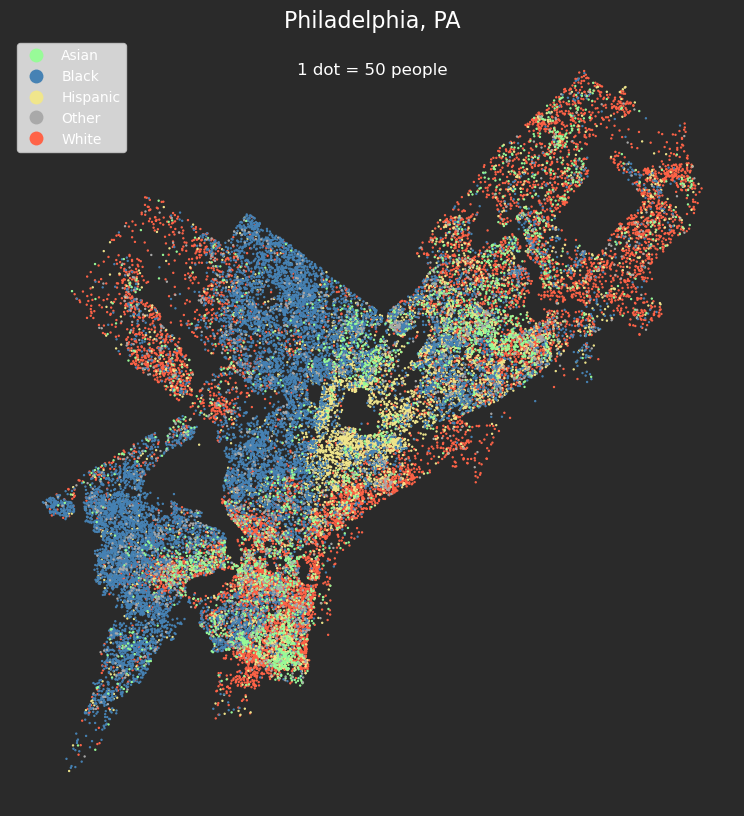

In [111]:
# Initialize the figure and axes
fig, ax = plt.subplots(figsize=(10, 10), facecolor="#2a2a2a")

# Plot
dot_map_3857.plot(
    ax=ax,
    column="field",
    categorical=True,
    legend=True,
    alpha=1,
    markersize=0.5,
    cmap=cmap,
    legend_kwds=dict(labelcolor="white"),
)

# format
ax.set_title("Philadelphia, PA", fontsize=16, color="white")
ax.text(
    0.5,
    0.95,
    "1 dot = 50 people",
    fontsize=12,
    transform=ax.transAxes,
    ha="center",
    color="white",
)
ax.set_axis_off()

## That's it!

- Next week: working with big (1M+ rows) datasets
- See you on Monday!